In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [4]:
CSV_PATH = "raw_wholesale_customers.csv"

FEATURES = ["Fresh", "Milk", "Grocery",
            "Frozen", "Detergents_Paper", "Delicassen"]
RANDOM_STATE = 42


In [5]:
# 1) Load dataset
# --------------------------------
df = pd.read_csv(CSV_PATH)
print("\n=== INITIAL SNAPSHOT ===")
print(df.head())


=== INITIAL SNAPSHOT ===
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [6]:
# 2) Select features + IQR cap
# L3: clip extreme spend values before scaling — same idea as house/loan pipelines
# --------------------------------
print("\n=== FEATURES HEAD (before IQR cap) ===")
print(df.head())



X = df[FEATURES].copy()



def iqr_fun(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper


low_fresh,  high_fresh = iqr_fun(X["Fresh"])
low_milk,    high_milk = iqr_fun(X["Milk"])
low_grocery, high_grocery = iqr_fun(X["Grocery"])
low_frozen,  high_frozen = iqr_fun(X["Frozen"])
low_det,     high_det = iqr_fun(X["Detergents_Paper"])
low_deli,    high_deli = iqr_fun(X["Delicassen"])

X["Fresh"] = X["Fresh"].clip(lower=low_fresh,  upper=high_fresh)
X["Milk"] = X["Milk"].clip(lower=low_milk,    upper=high_milk)
X["Grocery"] = X["Grocery"].clip(lower=low_grocery, upper=high_grocery)
X["Frozen"] = X["Frozen"].clip(lower=low_frozen,  upper=high_frozen)
X["Detergents_Paper"] = X["Detergents_Paper"].clip(
    lower=low_det, upper=high_det)
X["Delicassen"] = X["Delicassen"].clip(lower=low_deli, upper=high_deli)

df[FEATURES] = X
print("\n=== IQR CAP SUMMARY FOR EACH FEATURE ===")
print(
    f"Fresh             low={low_fresh:.2f}  high={high_fresh:.2f}  |  after cap min={X['Fresh'].min():.2f}  max={X['Fresh'].max():.2f}")
print(
    f"Milk              low={low_milk:.2f}  high={high_milk:.2f}  |  after cap min={X['Milk'].min():.2f}  max={X['Milk'].max():.2f}")
print(
    f"Grocery           low={low_grocery:.2f}  high={high_grocery:.2f}  |  after cap min={X['Grocery'].min():.2f}  max={X['Grocery'].max():.2f}")
print(
    f"Frozen            low={low_frozen:.2f}  high={high_frozen:.2f}  |  after cap min={X['Frozen'].min():.2f}  max={X['Frozen'].max():.2f}")
print(
    f"Detergents_Paper  low={low_det:.2f}  high={high_det:.2f}  |  after cap min={X['Detergents_Paper'].min():.2f}  max={X['Detergents_Paper'].max():.2f}")
print(
    f"Delicassen        low={low_deli:.2f}  high={high_deli:.2f}  |  after cap min={X['Delicassen'].min():.2f}  max={X['Delicassen'].max():.2f}")



print("\n=== FEATURES HEAD (after IQR cap) ===")
print(X.head())


=== FEATURES HEAD (before IQR cap) ===
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

=== IQR CAP SUMMARY FOR EACH FEATURE ===
Fresh             low=-17581.25  high=37642.75  |  after cap min=3.00  max=37642.75
Milk              low=-6952.88  high=15676.12  |  after cap min=55.00  max=15676.12
Grocery           low=-10601.12  high=23409.88  |  after cap min=3.00  max=23409.88
Frozen            low=-3475.75  high=7772.25  |  after cap min=25.00  max=7772.25
Detergents_Paper  low=-5241.12  high=9419.88  |  after cap min=3.00  max=9419.88
Delicassen        low=-1709.7

In [7]:
# 3) Scale features
# --------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nScaled shape:", X_scaled.shape)
print(X_scaled)


Scaled shape: (440, 6)
[[ 0.12857261  1.05158597  0.04926747 -0.95324427  0.09579175  0.06589216]
 [-0.42162716  1.08673463  0.35386453 -0.30973493  0.30651872  0.47075856]
 [-0.49064723  0.85804007  0.06793486 -0.04243744  0.38243489  2.46943983]
 ...
 [ 0.31112285  2.38267048  2.45460914 -0.86054235  2.39229863  0.55487464]
 [-0.10466425 -0.70014133 -0.7595007  -0.61070442 -0.75732904  0.7933576 ]
 [-0.84025742 -0.76473271 -0.71730938 -1.01518413 -0.65213577 -1.1228252 ]]


In [8]:
# 4) Elbow method (print SSE)
# --------------------------------
import warnings
warnings.filterwarnings("ignore", category=UserWarning) #this two line is not included the assignment just i will detected warnings 


print("\n=== ELBOW METHOD (SSE per k) ===")
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
    km.fit(X_scaled)
    print(f"k={k} → SSE={km.inertia_:.2f}")




=== ELBOW METHOD (SSE per k) ===
k=1 → SSE=2640.00
k=2 → SSE=1728.19
k=3 → SSE=1363.45
k=4 → SSE=1202.41
k=5 → SSE=1070.15
k=6 → SSE=964.76
k=7 → SSE=921.14
k=8 → SSE=776.63
k=9 → SSE=726.88
k=10 → SSE=707.41


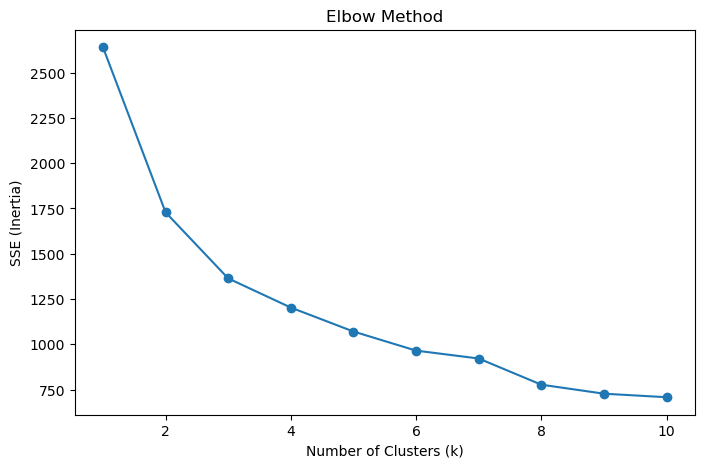

In [9]:


#showing as a diagram

import matplotlib.pyplot as plt

sse = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), sse, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method")

plt.show()


In [10]:
##5
# --------------------------------
# 
K=5

kmeans = KMeans(n_clusters=K, n_init="auto", random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels.astype(int)
print("\n=== SAMPLE WITH CLUSTERS ===")
print(df.head())


=== SAMPLE WITH CLUSTERS ===
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   
3        1       3  13265.0  1196.0   4221.0  6404.0             507.0   
4        2       3  22615.0  5410.0   7198.0  3915.0            1777.0   

   Delicassen  Cluster  
0     1338.00        0  
1     1776.00        0  
2     3938.25        0  
3     1788.00        3  
4     3938.25        3  


In [11]:
# 6) Evaluate clustering
# --------------------------------
sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)
print("\n=== METRICS ===")
print(f"Silhouette Score : {sil:.3f} (closer to +1 is better)")
print(f"Davies–Bouldin   : {dbi:.3f} (lower is better)")


# Cluster centers (back to original units)
# --------------------------------
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers_original, columns=FEATURES)
centers_df.index.name = "Cluster"

print("\n=== CLUSTER CENTERS (Original Units) ===")
print(centers_df)



=== METRICS ===
Silhouette Score : 0.283 (closer to +1 is better)
Davies–Bouldin   : 1.270 (lower is better)

=== CLUSTER CENTERS (Original Units) ===
                Fresh          Milk       Grocery       Frozen  \
Cluster                                                          
0         9202.671053   6833.302632   9104.118421  1326.157895   
1         8376.230366   2150.649215   3160.628272  1646.329843   
2        17461.540000  13805.605000  17524.120000  4120.570000   
3        22346.698864   3409.137784   3969.329545  5819.596591   
4         4916.983333  10768.854167  18350.133333  1212.366667   

         Detergents_Paper   Delicassen  
Cluster                                 
0             3280.118421  1871.756579  
1              779.251309   674.015707  
2             5460.565000  3583.640000  
3              583.068182  1566.946023  
4             7780.018750   981.366667  


Second Clustering Algorithm: Agglomerative Clustering
I chose Agglomerative Clustering (Hierarchical Clustering) as the second clustering algorithm.

Agglomerative Clustering is a hierarchical clustering method that starts by considering each customer as an individual cluster. It then gradually merges the most similar customers together based on their distance until the desired number of clusters is reached.

This algorithm is suitable for wholesale customer segmentation because it can group customers based on similar purchasing behaviors.In this project, customers are segmented according to their spending patterns across six features: Fresh, Milk, Grocery, Frozen, Detergents_Paper, and Delicassen.

I selected this algorithm because it provides a different clustering approach compared with K-Means. While K-Means assigns customers to clusters based on cluster centers, Agglomerative Clustering builds clusters by analyzing relationships and similarities between customers. This can help identify meaningful customer groups and compare the results with the K-Means model.

Research source: IBM – Hierarchical Clustering Explained

In [12]:
# --------------------------------
# Train Agglomerative Clustering
# --------------------------------

from sklearn.cluster import AgglomerativeClustering

# Create model
agg = AgglomerativeClustering(n_clusters=5)

# Train model on the same scaled features
agg_labels = agg.fit_predict(X_scaled)

# Add cluster column to dataframe
df["Agg_Cluster"] = agg_labels.astype(int)

print("\n=== SAMPLE WITH AGGLOMERATIVE CLUSTERS ===")
print(df.head())


=== SAMPLE WITH AGGLOMERATIVE CLUSTERS ===
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   
3        1       3  13265.0  1196.0   4221.0  6404.0             507.0   
4        2       3  22615.0  5410.0   7198.0  3915.0            1777.0   

   Delicassen  Cluster  Agg_Cluster  
0     1338.00        0            4  
1     1776.00        0            4  
2     3938.25        0            0  
3     1788.00        3            3  
4     3938.25        3            0  


In [13]:
##8

from sklearn.metrics import silhouette_score

# Silhouette Score for K-Means
kmeans_sil = silhouette_score(X_scaled, labels)

# Silhouette Score for Agglomerative
agg_sil = silhouette_score(X_scaled, agg_labels)

print("=== SILHOUETTE SCORE COMPARISON ===")
print(f"K-Means Silhouette Score        : {kmeans_sil:.3f}")
print(f"Agglomerative Silhouette Score : {agg_sil:.3f}")

=== SILHOUETTE SCORE COMPARISON ===
K-Means Silhouette Score        : 0.283
Agglomerative Silhouette Score : 0.218


## Comparison of Clustering Methods

The Silhouette Score was used to compare the performance of K-Means and Agglomerative Clustering.

K-Means achieved a Silhouette Score of **0.283**, while Agglomerative Clustering achieved a Silhouette Score of **0.218**.

Based on these results, **K-Means produced better-separated clusters** because it achieved a higher Silhouette Score. 
This means that the customers within the same cluster were more similar to each other, while the differences between different clusters were clearer.

K-Means performed better in this wholesale customer segmentation task because the dataset contains numerical spending features with relatively 
clear customer purchasing patterns. K-Means works well when customers can be grouped based on their distance from cluster centers, which helped 
it create more distinct segments. In contrast, Agglomerative Clustering builds clusters by gradually merging similar customers, and for this dataset 
it produced clusters with more overlap between groups.


In [14]:
# --------------------------------
sample_idx = [0, 1, 2]
sanity = df.loc[sample_idx, ["Channel", "Region"] + FEATURES + ["Cluster","Agg_Cluster"]]
print("\n=== SANITY CHECK (3 Clients) ===")
print(sanity)



=== SANITY CHECK (3 Clients) ===
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   

   Delicassen  Cluster  Agg_Cluster  
0     1338.00        0            4  
1     1776.00        0            4  
2     3938.25        0            0  


In [15]:
# 10) Save labeled dataset
# --------------------------------
OUT_PATH = "segmented_wholesale_customers.csv"

df.to_csv(OUT_PATH, index=False)
print(f"\nSaved clustered dataset → {OUT_PATH}")


Saved clustered dataset → segmented_wholesale_customers.csv
